In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import h5py
import sys
sys.path.append('../')
import analysis_utils as utils

from scipy.signal import welch
from scipy.signal.windows import hann
from scipy.fft import fft, fftfreq, rfft, irfft, rfftfreq
from scipy.special import voigt_profile
from scipy.optimize import curve_fit

yale_colors = ['#00356b', '#286dc0', '#63aaff', '#4a4a4a']
utils.load_plotting_setting()

In [2]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/dm_nanospheres/analysis_notebooks/../analysis_utils.py'>

In [3]:
rho = 2000 # kg/m^3
m = rho * (83e-9)**3 * 4 * np.pi / 3

c = 299792458  # m/s
kb = 1.38e-23
hbar = 1.054571817e-34
omega0 = 2 * np.pi * 50500
# omega0 = 2 * np.pi * 50430.2978515625

SI2ev = (1 / 1.6e-19) * c

zpf = np.sqrt(hbar / (2 * m * omega0))
pzpf = np.sqrt(hbar * m * omega0 / 2)

In [4]:
## Likelihood fit (doesn't work very well)

# from scipy.optimize import minimize

# def nll_psd(A, omega0, sigma, gamma, omega, sz):
#     idx_fit = np.logical_and(omega > 40000*2*np.pi, omega < 700000*2*np.pi)

#     omega_fit = omega[idx_fit]
#     mui = voigt(omega_fit, A, omega0, sigma, gamma)
#     # mui = A / ((omega_fit**2 - omega0**2)**2 + gamma**2 * omega_fit**2)
#     mui[mui < 1e-30] = 1e-30

#     ni = sz[idx_fit]
#     return np.sum(np.nan_to_num(mui - ni * np.log(mui)))

# def minimize_nll_psd(omega, sz, bounds=None):
#     args = (omega, sz)

#     res = minimize(fun=lambda x: nll_psd(*x, *args),
#                    x0=[5e-18, 50000*2*np.pi, 50*2*np.pi, 1*2*np.pi],
#                    method='Nelder-Mead',
#                    bounds=[(1e-30, 1), (None, None), (None, None), (1e-5, 100)],
#                    options={'disp' : False,
#                             'maxiter': 5000000,
#                             'maxfev': 5000000,
#                             'adaptive': False,
#                             'fatol': 1e-6,
#                             }
#                     )

#     if res.success:
#         return res.fun, res.x
#     else:
#         return np.nan, np.full(2, np.nan)
    
# fun, x_fit = minimize_nll_psd(ff*2*np.pi, sz_measured)
# A, omega0, sigma, gamma = x_fit

# print(x_fit)

In [5]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3), (E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C

#### Derive calibration factor from electric calibration

In [6]:
drive_freq = [143000, 163000]
drive_vpp  = [1, 2, 3, 4]

c_mvs_freqs = [[], []]
for i, freq in enumerate(drive_freq):
    for vpp in drive_vpp:
        data_files = [rf"/Users/yuhan/work/nanospheres/data/pulse_calibration/sphere_20250406/20250412_electric_calibration_2e-8mbar/20250412_d_m8e_{int(freq/1000)}khz_{vpp}vpp_trapping_0.hdf5"]
        c_mvs = utils.get_c_mv(data_files, [vpp], freq*2*np.pi, passband=(freq-1300, freq+1300), charge=8, n_chunk=6, efield=138)

        c_mvs_freqs[i].append(c_mvs)

In [7]:
c_mv = np.mean(np.asarray(c_mvs_freqs))
print(fr'Calibration factor C_mv: {c_mv} \pm {np.std(np.asarray(c_mvs_freqs))}')

Calibration factor C_mv: 6.711030676159362e-08 \pm 2.0316969808876543e-09


#### Estimate scattered power and noise based on the measured reheating rate

In [8]:
gamma_reheating = 17916 * 2 * np.pi
gamma_reheating_gas = 1100 * 2 * np.pi
gamma_damping_reheating = 0.46 * 2 * np.pi

S_ff_ba = 4 * pzpf**2 * gamma_reheating         # N^2 / Hz
S_zz_imp = (zpf**2) / (4 * gamma_reheating)     # m^2 / Hz

# Estimate the one-sided thermal force spectral density from the
# measured gas heating rate
small_gamma_th_kb_T = gamma_reheating_gas * (hbar * omega0)
sf_th = 4 * small_gamma_th_kb_T * m
print(f'Measured gas force spectrum: {sf_th} N^2/Hz')

Measured gas force spectrum: 4.4313171557356005e-42 N^2/Hz


In [9]:
kb = 1.38e-23

p_mbar = 1.7e-8
p_pascal = p_mbar * 100

R = 8.3144  # J/(mol K)
m_gas = 2.016e-3 * 0.6 + 18.01528e-3 * 0.4  # kg / mol
T = 292  # K
vbar = np.sqrt(8 * R * T / (np.pi * m_gas))  # m/s

r_sphere_0 = 83e-9
m_sphere_0 = 2000 * 4/3 * np.pi * r_sphere_0**3

gamma_th = (64/3) * r_sphere_0**2 * p_pascal / (m_sphere_0 * vbar)
sf_th_th = 4 * kb * T * gamma_th * m_sphere_0
print(f'Theory gas force spectrum: {sf_th_th} N^2/Hz')

Theory gas force spectrum: 4.698446077247262e-42 N^2/Hz


In [10]:
na = 0.77
lambd = 1064e-9
k = 2 * np.pi / lambd

A = calc_geometric_factor(na=na)
p_sca = S_ff_ba / ((A**2 + 2/5) * hbar * k / c)

print(f'Scattered laser power = {p_sca * 1e6:.2f} uW')
print(f'Backaction noise (one-sided): {S_ff_ba * 2:.3e} N^2/Hz')
print(f'Imprecision noise floor (one-sided): {S_zz_imp * 2:.3e} m^2/Hz')

Scattered laser power = 15.91 uW
Backaction noise (one-sided): 7.217e-41 N^2/Hz
Imprecision noise floor (one-sided): 1.541e-28 m^2/Hz


#### Plot the measured spectrum and estimate info collection efficiency

In [11]:
# frerq, vpp = 163000, 4
# f = h5py.File(f'/Users/yuhan/work/nanospheres/data/pulse_calibration/sphere_20250406/20250412_electric_calibration_2e-8mbar/20250412_d_m8e_{int(freq/1000)}khz_{vpp}vpp_trapping_0.hdf5')
f = h5py.File('/Users/yuhan/work/nanospheres/data/pulse_calibration/sphere_20250406/20250412_electric_calibration_2e-8mbar/20250412_d_m8e_nodrive_3.hdf5', 'r')

dtt = f['data'].attrs['delta_t']
fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V
zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

f.close()

In [12]:
n_spectrum = 10
n_chunk = 400
# n_chunk = 5

size_per_chunk = int(zz.size / n_chunk)
hann_window = hann(size_per_chunk)

# Correction factor for Hann windowing
# See https://dsp.stackexchange.com/questions/93512/effects-of-hanning-window-on-power
hann_psd_scaling = np.sum(hann_window**2)

ff, s_zzs, s_ffs = None, [], []
for i in range(n_spectrum):
    zz_calc = zz[i*size_per_chunk : (i+1)*size_per_chunk]
    zz_windowed = hann_window * zz_calc

    s_zz = np.abs(rfft(zz_windowed))**2 / (fs * hann_psd_scaling)
    s_zzs.append(s_zz)

    ff = rfftfreq(size_per_chunk, dtt)
    f0 = ff[ff > 30000][np.argmax(s_zz[ff > 30000])]
    omega0 = f0 * 2 * np.pi
    # gamma0 = 0.34 * 2 * np.pi
    gamma0 = (ff[1] - ff[0]) * 2 * np.pi

    omega = ff * 2 * np.pi
    chi_omega = 1 / (m * (omega0**2 - omega**2 - 1j * gamma0 * omega))
    # s_ffs.append(s_zz / (np.abs(chi_omega)**2))

s_zs = 2 * np.array(s_zzs)
# s_fs = 2 * np.array(s_ffs)

sz_measured = np.mean(s_zs, axis=0) * c_mv**2
# sf_measured = np.mean(s_fs, axis=0) * c_mv**2

idx_max = np.argmax(sz_measured[ff > 30000])
omega0 = 2 * np.pi * ff[ff > 30000][idx_max]
gamma0 = (ff[1] - ff[0]) * 2 * np.pi 

omega = ff * 2 * np.pi
chi_omega = 1 / (m * (omega0**2 - omega**2 - 1j * gamma0 * omega))
sf_measured = sz_measured / (np.abs(chi_omega) ** 2)

idx_int = np.logical_and(ff>0, ff<200000)
# idx_int = np.logical_and(ff>40000, ff<60000)

# There is a factor of 4 when integrating over the single-sided spectral density!
dp_kev = np.sqrt( 1/( np.trapz(4/sf_measured[idx_int], x=ff[idx_int]*2*np.pi) /(2*np.pi) ) ) * SI2ev / 1000

print(f'Predicted impulse sensitivity: {dp_kev:.3f} keV/c')

Predicted impulse sensitivity: 61.123 keV/c


In [13]:
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

def gaussian_convolved_lineshape(omega, A, omega0, sigma, gamma):
    xx_gauss = np.arange(-400*2*np.pi, 400*2*np.pi, 1)
    gauss_kernel = gauss(xx_gauss, A=1, mu=0, sigma=sigma)
    gauss_kernel /= np.sum(gauss_kernel)

    xx = np.arange(20000*2*np.pi, 120000*2*np.pi, 1)
    actual_lineshape = A / ((xx**2 - omega0**2)**2 + gamma**2 * xx**2)
    
    convolved_lineshape = np.convolve(gauss_kernel, actual_lineshape, 'same')
    return np.interp(omega, xx, convolved_lineshape)

def voigt(xx, A, x0, sigma, gamma):
    return A * voigt_profile(xx-x0, sigma, gamma)

def fit_sigma_voigt(ff, sz, gamma=None):
    fit_idx_voigt = np.logical_and(ff > 45000, ff < 55000)

    popt, pcov = curve_fit(lambda xx, A, f0, sigma, gamma: voigt(xx, A, f0, sigma, gamma), ff[fit_idx_voigt]*2*np.pi, sz[fit_idx_voigt], 
                           p0=[3e-18, 50500*2*np.pi, 50*2*np.pi, 1*2*np.pi], sigma=sz[fit_idx_voigt])
    
    # If don't want to fit for gamma
    # popt, pcov = curve_fit(lambda xx, A, f0, sigma: voigt(xx, A, f0, sigma, gamma), ff[fit_idx_voigt]*2*np.pi, sz[fit_idx_voigt], 
    #                        p0=[1e-18, 50000*2*np.pi, 43*2*np.pi], sigma=sz[fit_idx_voigt])
    
    return popt

def fit_gaussian_convolved_lineshape(ff, sz):
    fit_idx = np.logical_and(ff > 45000, ff < 70000)

    popt, pcov = curve_fit(lambda xx, A, omega0, sigma, gamma: gaussian_convolved_lineshape(xx, A, omega0, sigma, gamma), ff[fit_idx]*2*np.pi, sz[fit_idx], 
                           p0=[1e-18, 50000*2*np.pi, 400*2*np.pi, 0.43*2*np.pi], sigma=sz[fit_idx])
    return popt

A, omega0, sigma, gamma_voigt = fit_sigma_voigt(ff, sz_measured)
print(A, omega0/(2*np.pi), sigma, gamma_voigt)

# A, f0, sigma, gamma = fit_gaussian_convolved_lineshape(ff, sz_measured)
# print(A, f0/(2*np.pi), sigma, gamma)

5.9945763009176e-18 50497.60923931324 375.67345323413576 6.644451758689284


In [14]:
gamma = gamma_voigt * 2

# Use the sigma and gamma extracted from voigt fit
# to calculate the broadend lineshape
# gamma/2 is the corresponding Lorentzian linewidth if the true oscillator
# had damping gamma
convolved_lineshape = gaussian_convolved_lineshape(ff*2*np.pi, 1, omega0, sigma, gamma)
chi_2_convolved = (1 / (m**2)) * convolved_lineshape

# convolved_lineshape = voigt(ff*2*np.pi, 1, omega0, sigma, gamma)
# chi_2_convolved = (1 / (4 * m**2)) * convolved_lineshape * (np.pi / gamma)

sf_measured_convolved = sz_measured / (chi_2_convolved)

idx_int = np.logical_and(ff>30000, ff<100000)
dp_kev = np.sqrt( 1/( np.trapz(4/sf_measured_convolved[idx_int], x=ff[idx_int]*2*np.pi) /(2*np.pi) ) ) * SI2ev / 1000

print(f'Predicted impulse sensitivity: {dp_kev:.3f} keV/c')

Predicted impulse sensitivity: 64.825 keV/c


Estimated measurement rate: 1.904 \pm 0.286 kHz
Estimated information collection efficiency: 0.1033


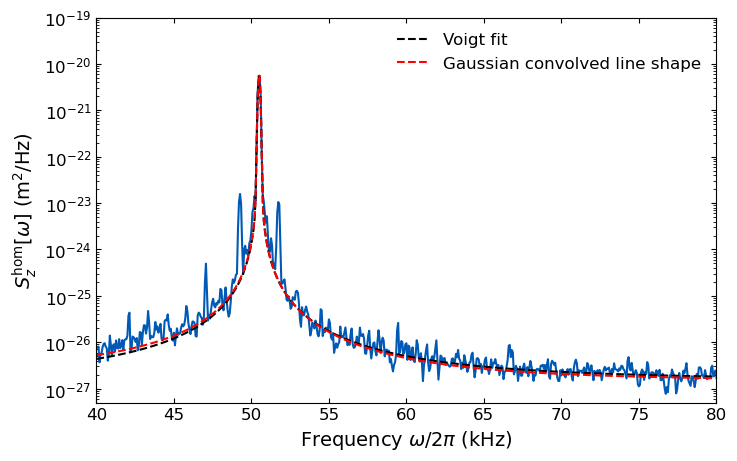

In [15]:
omega = ff * 2 * np.pi
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Take the imprecision noise to be averaged value
# from 500 to 750 kHz
fit_idx = np.logical_and(ff > 500000, ff < 750000)
sz_noisefloor = np.mean(sz_measured[fit_idx])

ax.plot(ff/1000, sz_measured, '-', color='#005AB5')
# ax.plot(ff/1000, A / ((omega**2 - omega0**2)**2 + gamma**2 * omega**2))
ax.plot(ff/1000, voigt(omega, A, omega0, sigma, gamma_voigt) + sz_noisefloor, 'k--', label='Voigt fit')

convolved_lineshape = gaussian_convolved_lineshape(ff*2*np.pi, 1, omega0, sigma, gamma_voigt*2)
scaling_factor = (sz_measured[ff>30000][np.argmax(sz_measured[ff > 30000])] - sz_noisefloor) / convolved_lineshape[ff>30000][np.argmax(sz_measured[ff > 30000])]
ax.plot(ff/1000,  scaling_factor * convolved_lineshape + sz_noisefloor, 'r--', label='Gaussian convolved line shape')

ax.legend(frameon=False)
ax.set_yscale('log')
ax.set_xlim(40, 80)
ax.set_ylim(5e-28, 1e-19)

ax.set_xlabel(r'Frequency $\omega/2 \pi$ (kHz)')
ax.set_ylabel(r'$S^{\mathrm{hom}}_z$[$\omega$] (m$^2$/Hz)')

eta = S_zz_imp * 2 / sz_noisefloor
# eta = S_zz_imp * 2 / x_fit[4]
gamma_meas_khz = zpf**2 / (4 * sz_noisefloor / 2) / (1000 * 2*np.pi)

print(fr'Estimated measurement rate: {gamma_meas_khz:.3f} \pm {gamma_meas_khz * 0.15:.3f} kHz')
print(f'Estimated information collection efficiency: {gamma_meas_khz / (gamma_reheating/(2*np.pi*1000) + 0.511):.4f}')

# print(f'Estimated information collection efficiency: {eta:.4f}')


#### Theory curves

In [16]:
def gaussian_convolved_chi(omega, m, omega0, sigma, gamma, chi_inv=False):
    xx_gauss = np.arange(-400*2*np.pi, 400*2*np.pi, 1)
    gauss_kernel = gauss(xx_gauss, A=1, mu=0, sigma=sigma)
    gauss_kernel /= np.sum(gauss_kernel)

    xx = np.arange(20000*2*np.pi, 120000*2*np.pi, 1)
    # Calculate theh convolved 1/chi instead of chi
    if not chi_inv:
        actual_chi = (1/m) / ((xx**2 - omega0**2) - 1j * gamma * xx)
    else:
        actual_chi = m * ((xx**2 - omega0**2) - 1j * gamma * xx)

    real_chi = np.real(actual_chi)
    imag_chi = np.imag(actual_chi)

    convolved_real_chi = np.convolve(gauss_kernel, real_chi, 'same')
    convolved_imag_chi = np.convolve(gauss_kernel, imag_chi, 'same')

    return np.interp(omega, xx, convolved_real_chi), np.interp(omega, xx, convolved_imag_chi)


In [17]:
# Always integrate over double-sided spectra to avoid confusion...
# also numerical integration over one-sided spectra gives incorrect values sometimes
# look into more in the future
omega_theory = np.linspace(-2*200e3*np.pi, 2*200e3*np.pi, 2000000)

# chi_ba = (1 / m) / (omega0**2 - omega_theory**2 - gamma * omega_theory * 1j) # Complex susceptibility
convolved_lineshape_theory = gaussian_convolved_lineshape(omega_theory, 1, omega0, sigma, gamma)
chi_2_convolved_theory = (1 / (m**2)) * convolved_lineshape_theory

convolved_real_chi, convolved_imag_chi = gaussian_convolved_chi(omega_theory, m, omega0, sigma, gamma)
S_zz_zpf = hbar * convolved_imag_chi

S_ff_zpf = hbar * m * gamma * omega0

# S_zz_zpf = 0.5 * zpf**2 * gamma * convolved_lineshape_theory * 1e10

# ZPF force noise (single sided)
# S_f_zpf = 2 * hbar * m * gamma * omega0

# SQL curves
# S_z_sql = 2 * hbar * (np.abs(chi_ba))
# S_f_sql = 2 * hbar / (np.abs(chi_ba))

In [18]:
Sf_total = np.full_like(omega_theory, sz_noisefloor/chi_2_convolved_theory) + np.full_like(omega_theory, 2*S_ff_ba + sf_th) + np.full_like(omega_theory, 2*S_ff_zpf)

idx_int = np.logical_and((omega_theory/(2*np.pi))>0, (omega_theory/(2*np.pi))<200000)
dp_kev_theory = np.sqrt( 1/( np.trapz(4/Sf_total[idx_int], x=omega_theory[idx_int] /(2*np.pi) ) )) * SI2ev / 1000
print(f'Predicted theory impulse sensitivity: {dp_kev_theory:.3f} keV/c')

idx_int = np.logical_and((omega_theory/(2*np.pi))>0, (omega_theory/(2*np.pi))<200000)

chi_omega_theory = 1 / (m * (omega0**2 - omega_theory**2 - 1j * gamma * omega_theory))
Sf_total_ideal = np.full_like(omega_theory, (2*S_zz_imp) / (np.abs(chi_omega_theory)**2) + np.full_like(omega_theory, 2*S_ff_ba))

dp_kev_theory_ideal = np.sqrt( 1/( np.trapz(4 / Sf_total_ideal[idx_int], x=omega_theory[idx_int]) /(2*np.pi) )) * SI2ev / 1000
print(fr'Predicted theory impulse sensitivity ($\eta$ = 1): {dp_kev_theory_ideal:.3f} keV/c')

Predicted theory impulse sensitivity: 44.598 keV/c
Predicted theory impulse sensitivity ($\eta$ = 1): 29.013 keV/c


In [19]:
print(sz_measured[ff>30000][np.argmax(sz_measured[ff>30000])])
print(np.max(2 * S_ff_ba * chi_2_convolved_theory))

5.50996794304979e-21
3.867227187745235e-21


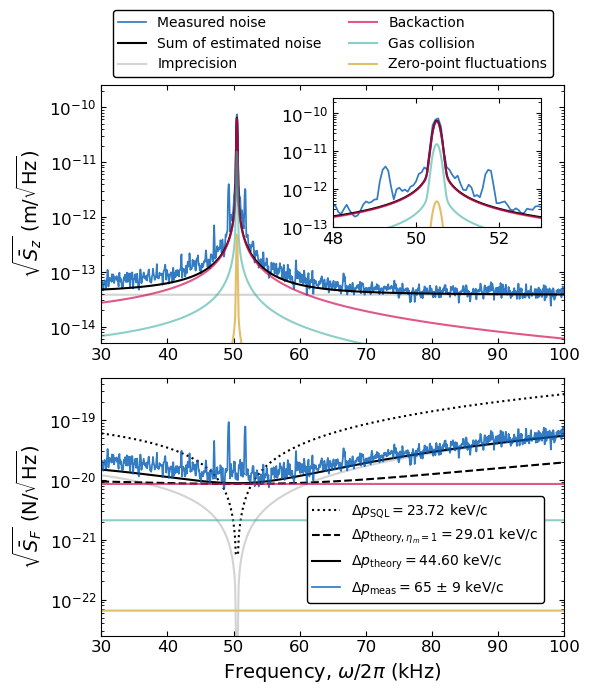

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(6, 7))

axes[0].plot(ff/1000, np.sqrt(sz_measured), '-', color='#005AB5', linewidth=1.25, alpha=0.8, label='Measured noise')

Sz_total = np.full_like(omega_theory, sz_noisefloor) + (2 * S_ff_ba + sf_th) * chi_2_convolved_theory + 2 * S_zz_zpf
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sz_total), 'k', linewidth=1.5, label='Sum of estimated noise')

axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, sz_noisefloor)), 'lightgrey', linewidth=1.5, label='Imprecision', zorder=-5)
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_ff_ba * chi_2_convolved_theory), color='#D41159', linewidth=1.5, label='Backaction', alpha=0.7)
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(sf_th * chi_2_convolved_theory), color='#40B0A6', linewidth=1.5, alpha=0.6, label='Gas collision')
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_zz_zpf), color='#E1BE6A', linewidth=1.5, label='Zero-point fluctuations')

Sf_total = np.full_like(omega_theory, sz_noisefloor/chi_2_convolved_theory) + np.full_like(omega_theory, 2*S_ff_ba + sf_th) + np.full_like(omega_theory, 2*S_ff_zpf)
min_dp_power_scale = 0.004247571552536903
dp_sql = np.sqrt(hbar * m * omega0) * SI2ev / 1000
Sf_total_dp_sql = np.full_like(omega_theory, (2 * S_zz_imp/min_dp_power_scale) / chi_2_convolved_theory + np.full_like(omega_theory, 2 * S_ff_ba * min_dp_power_scale))
Sf_total_ideal = np.full_like(omega_theory, (2 * S_zz_imp) / chi_2_convolved_theory + np.full_like(omega_theory, 2 * S_ff_ba))

axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sf_total_dp_sql), 'k:', linewidth=1.5, label=rf'$\Delta p_\mathrm{{SQL}} = $' + f'{dp_sql:.2f} keV/c')
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sf_total_ideal), 'k--', linewidth=1.5, label=r'$\Delta p_{\mathrm{theory}, \eta_m=1} = $' + f'{dp_kev_theory_ideal:.2f} keV/c')
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sf_total), 'k-', linewidth=1.5, label=rf'$\Delta p_\mathrm{{theory}} = $' + f'{dp_kev_theory:.2f} keV/c')
axes[1].plot(ff/1000, np.sqrt(sf_measured_convolved), '-', color='#005AB5', linewidth=1.25, alpha=0.8,
             label=r'$\Delta p_{\mathrm{meas}} = $' + fr'{dp_kev:.0f} $\pm$ {dp_kev * 0.5 * np.sqrt(0.2**2 + 0.2**2):.0f} keV/c')

axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2*S_zz_imp/eta/chi_2_convolved_theory)), 'lightgrey', linewidth=1.5, zorder=-5)
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2*S_ff_ba)) , color='#D41159', linewidth=1.5, alpha=0.7)
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, sf_th)), color='#40B0A6', linewidth=1.5, alpha=0.6)
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2* S_ff_zpf)), color='#E1BE6A', linewidth=1.5)

# axes[0].plot(omega_theory/(1000*2*np.pi), np.sqrt(S_z_sql), color='k', linestyle=':', linewidth=1.5, label='SQL')
# axes[1].plot(omega_theory/(1000*2*np.pi), np.sqrt(S_f_sql), color='k', linestyle=':', linewidth=1.5)

inset_ax = axes[0].inset_axes([0.5, 0.45, 0.45, 0.5])
inset_ax.plot(ff/1000, np.sqrt(sz_measured), '-', color='#005AB5', linewidth=1.25, alpha=0.8)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(Sz_total), 'k', linewidth=1.5)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2*S_zz_imp)/eta), 'lightgrey', linewidth=1.5, zorder=-5)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_ff_ba * chi_2_convolved_theory), color='#D41159', linewidth=1.5, alpha=0.7)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(sf_th * chi_2_convolved_theory), color='#40B0A6', linewidth=1.5, alpha=0.6)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_zz_zpf), color='#E1BE6A', linewidth=1.5)

# Set limits for the inset axes (optional)
inset_ax.set_yscale('log')
inset_ax.set_xlim(48, 53)
inset_ax.set_ylim(1e-13, 2.5e-10)
# axes[0].indicate_inset_zoom(inset_ax, edgecolor='k', linestyle='-')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(30, 100)

# axes[1].text(76, 2.5e-19, rf'$\Delta p_\mathrm{{SQL}}$= {dp_sql:.2f} keV/c', fontsize=10, color='k', rotation=8)
# axes[1].text(76, 7.5e-20, r'$\Delta p_{\mathrm{meas}} = $' + fr'{dp_kev:.0f} $\pm$ {dp_kev * 0.5 * np.sqrt(0.2**2 + 0.2**2):.0f} keV/c', fontsize=10, color='#005AB5', rotation=7)

axes[0].legend(frameon=True, fontsize=10, ncol=2, loc='upper center',
               bbox_to_anchor=(0.5, 1.32),
               framealpha=1, edgecolor='k')
axes[1].legend(frameon=True, fontsize=10, ncol=1, loc='lower center',
               bbox_to_anchor=(0.7, 0.1),
               framealpha=1, edgecolor='k')
axes[0].set_ylabel(r'$\sqrt{\bar{S}_{z}}$ (m/$\sqrt{\mathrm{Hz}}$)')
axes[1].set_ylabel(r'$\sqrt{\bar{S}_{F}}$ (N/$\sqrt{\mathrm{Hz}}$)')
axes[1].set_xlabel(r'Frequency, $\omega / 2 \pi$ (kHz)')

axes[0].set_ylim(5e-15, 2.5e-10)
axes[1].set_ylim(2.5e-23, 5e-19)

fig.tight_layout()
fig.align_labels()

# plt.savefig('../paper_plots/noise_budget_nanospheres.pdf', dpi=600)

#### Hypothetically scale the readout power to find the optimum point

In [21]:
dp_sql = np.sqrt(hbar * m * omega0) * SI2ev / 1000

power_scale = np.logspace(-8, 2, 200)
dp_ideal = np.empty_like(power_scale)

chi_omega_theory = 1 / (m * (omega0**2 - omega_theory**2 - 1j * gamma * omega_theory))
for i, scale in enumerate(power_scale):
    Sf_total_ideal_scaled = np.full_like(omega_theory, (2 * S_zz_imp/scale) / (np.abs(chi_omega_theory)**2) + np.full_like(omega_theory, 2 * S_ff_ba * scale))

    idx_int = np.logical_and((omega_theory/(2*np.pi))> 0, (omega_theory/(2*np.pi))<200000)
    dp_kev_theory_ideal_scaled = np.sqrt( 1/( np.trapz(4 / Sf_total_ideal_scaled[idx_int], x=omega_theory[idx_int]) /(2*np.pi))) * SI2ev / 1000
    dp_ideal[i] = dp_kev_theory_ideal_scaled

print(f'SQL sensitivity: {dp_sql:.2f} keV/c, `power_scale`={power_scale[np.argmin(dp_ideal)]}')
print(f'Minimum sensitivity: {np.min(dp_ideal):.2f} keV/c')

SQL sensitivity: 23.72 keV/c, `power_scale`=0.004247571552536903
Minimum sensitivity: 23.72 keV/c


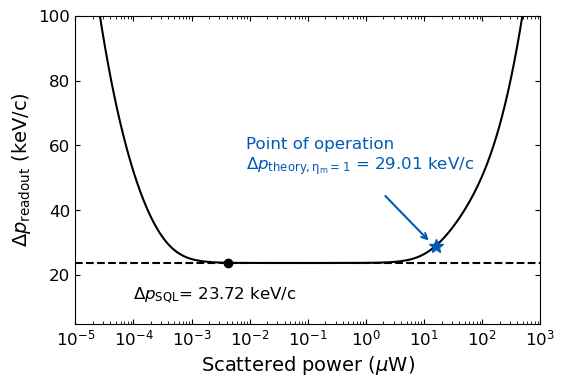

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(power_scale * p_sca / 1e-6, dp_ideal, 'k')
ax.plot(p_sca/1e-6, dp_kev_theory_ideal, '*', color='#005AB5', markersize=10)
ax.plot(power_scale[np.argmin(dp_ideal)], dp_ideal[np.argmin(dp_ideal)], 'ko')

# ax.vlines(x=p_sca/1e-6, ymin=0, ymax=150, color='#005AB5')
# ax.vlines(x=power_scale[np.argmin(dp_ideal)], ymin=0, ymax=150, color='k')
ax.hlines(y=dp_sql, xmin=1e-5, xmax=1e3, color='k', linestyles='--')

ax.set_xscale('log')

ax.set_xlim(1e-5, 1e3)
ax.set_ylim(5, 100)

ax.text(1e-4, 12.5, fr'$\Delta p_\mathrm{{SQL}}$= {dp_sql:.2f} keV/c', fontsize=12)
ax.text(8.5e-3, 52.5, 'Point of operation\n'+rf'$\Delta p_\mathrm{{theory, \eta_m = 1}}$ = {dp_kev_theory_ideal:.2f} keV/c', color='#005AB5', fontsize=12)
ax.annotate(
    '', 
    xytext=(2, 45), 
    xy=(13, 30),
    arrowprops=dict(arrowstyle='->', color='#005AB5', lw=1.5)
)


ax.set_xlabel(r'Scattered power ($\mu$W)')
ax.set_ylabel(r'$\Delta p_\mathrm{readout}$ (keV/c)')

plt.savefig('../paper_plots/sql_power_scaling.pdf', dpi=600)

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_26989/2741706128.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$z$ ($z_{\mathrm{zpf}}$)')
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_26989/2741706128.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('$p_z$ ($p_{\mathrm{zpf}}$)')


Text(0, 0.5, '$p_z$ ($p_{\\mathrm{zpf}}$)')

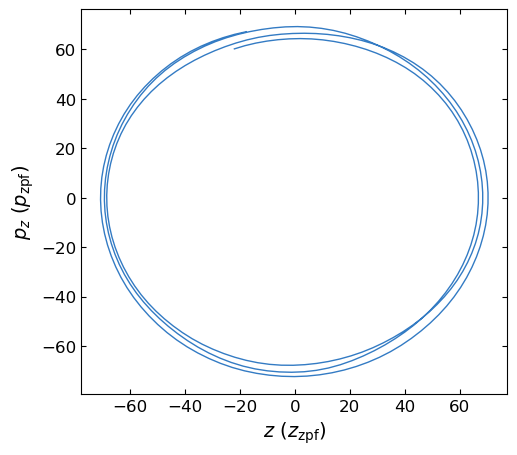

In [632]:
zz = zz_bp * c_mv                  # position [m]
pp = m * np.gradient(zz) / (2e-7)  # momentum; [kg] * [m/s]

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))

lb, ub = 2000, 2300
ax.plot(zz[lb:ub]/zpf, pp[lb:ub]/pzpf, '-', alpha=0.8, linewidth=1, color='#005AB5')

ax.set_xlabel('$z$ ($z_{\mathrm{zpf}}$)')
ax.set_ylabel('$p_z$ ($p_{\mathrm{zpf}}$)')

## Below is old, unused code

In [32]:
def bad_detection_quality(zz_windowed, zz_bp_windowed):
    # Z signal out of balance, meaning that homodyne losing lock
    if np.abs(np.mean(zz_windowed)) > 0.25:
        return True
    
    if np.max(np.abs(zz_windowed)) > 0.95:
        return True

    # Check the sum over 10 indices to see if there
    # is a consecutive period of very small signal after bandpass
    convolved = np.convolve(np.abs(zz_bp_windowed),np.ones(10, dtype=int), 'valid')
    if np.sum(convolved < 1e-3) > 0:
        return True

## Make a nice figure

(-1.5, 1.5)

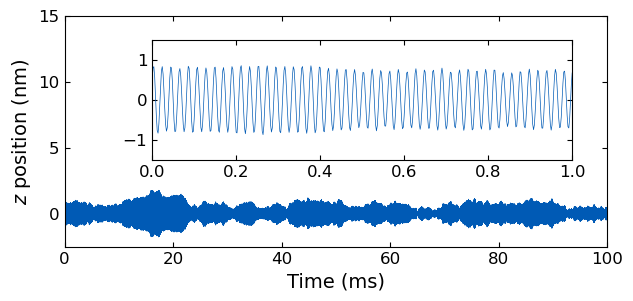

In [34]:
window_length = 5000
f = h5py.File('/Users/yuhan/work/nanospheres/data/dm_data/sphere_20250103/20250111_1e-8mbar_8e_alignment1_long/20250111_d_17.hdf5', 'r')

dtt = f['data'].attrs['delta_t']
fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V

zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

zz_shaped = np.reshape(zz, (int(zz.size / window_length), window_length))
zz_bp_shaped = np.reshape(zz_bp, (int(zz_bp.size / window_length), window_length))

f.close()

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

tt = np.arange(0, zz_bp.size) * 2e-6
ax.plot((tt-20) / 1e-3, zz_bp * c_mv/1e-9, color='#005AB5', linewidth=0.5)

ax.set_xlim(0, 100)
ax.set_ylim(-2.5, 15)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('$z$ position (nm)')

left, bottom, width, height = [0.25, 0.4, 0.6, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])

ax2.plot((tt-20) / 1e-3, zz_bp * c_mv/1e-9, color='#005AB5', linewidth=0.5)
ax2.set_xlim(0, 1)
ax2.set_ylim(-1.5, 1.5)



Text(0, 0.5, 'ASD (m/$\\sqrt{\\mathrm{Hz}}$)')

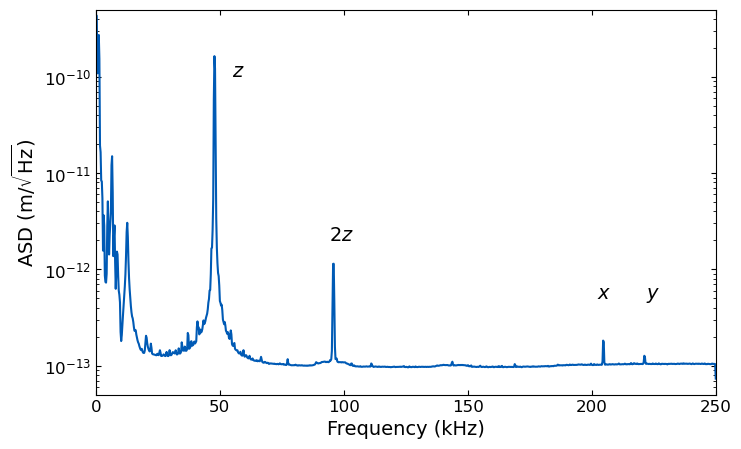

In [35]:
ff_long, pp_long = welch(zz, fs=500000, nperseg=2**11)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(ff_long/1000, np.sqrt(pp_long)*c_mv, color='#005AB5')
ax.set_yscale('log')
ax.set_xlim(0, 250)
ax.set_ylim(5e-14, 5e-10)

ax.text(55, 1e-10, r'$z$', fontsize=14)
ax.text(94, 2e-12, r'$2z$', fontsize=14)

ax.text(202, 5e-13, r'$x$', fontsize=14)
ax.text(222, 5e-13, r'$y$', fontsize=14)

ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel(r'ASD (m/$\sqrt{\mathrm{Hz}}$)')


Text(0, 0.5, '$S_{z, \\mathrm{hom}}[\\Omega]$ ((m$^2$/Hz)')

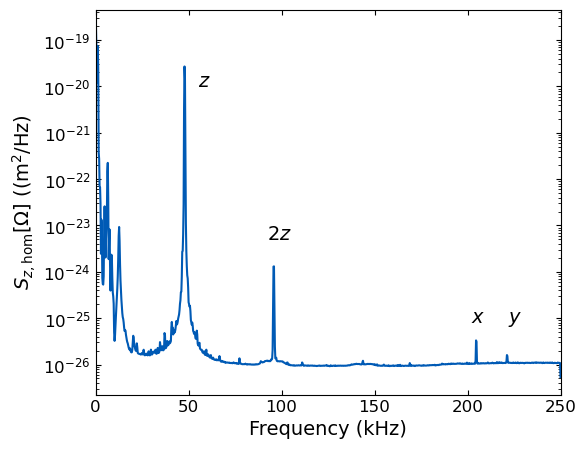

In [25]:
ff_long, pp_long = welch(zz, fs=500000, nperseg=2**11)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(ff_long/1000, pp_long*c_mv**2, color='#005AB5')

ax.set_yscale('log')
ax.set_xlim(0, 250)
# ax.set_ylim(5e-14, 5e-10)

ax.text(55, 1e-20, r'$z$', fontsize=14)
ax.text(92, 5e-24, r'$2z$', fontsize=14)

ax.text(202, 8e-26, r'$x$', fontsize=14)
ax.text(222, 8e-26, r'$y$', fontsize=14)

ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel(r'$S_{z, \mathrm{hom}}[\Omega]$ ((m$^2$/Hz)')


## Noise budget

In [33]:
window_length = 5000
file_idx = [56, 57, 58]

z_pp, f_pp = [], []

z_pp_welch, f_pp_welch = [], []
ff_welch = None

for idx in file_idx:
    f = h5py.File(f'/Users/yuhan/work/nanospheres/data/dm_data/sphere_20250103/20250117_8e-9mbar_0e_alignment1_long/20250117_d_{idx}.hdf5', 'r')

    dtt = f['data'].attrs['delta_t']
    fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
    zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V
    zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)
    zz_shaped = np.reshape(zz, (int(zz.size / window_length), window_length))
    zz_bp_shaped = np.reshape(zz_bp, (int(zz_bp.size / window_length), window_length))

    for i, zz in enumerate(zz_shaped):
        _, pp_welch = welch(zz, fs=500000, nperseg=2**12)
        ff_welch, pp_welch_bp = welch(zz_bp_shaped[i], fs=500000, nperseg=2**12)

        zzk = rfft(zz)
        zzk_bp = rfft(zz_bp_shaped[i])

        if bad_detection_quality(zz, zz_bp_shaped[i]):
            continue

        ff = rfftfreq(zz.size, dtt)
        pp = np.abs(zzk)**2 / (zz.size / dtt)
        pp_bp = np.abs(zzk_bp)**2 / (zz.size / dtt)

        # # if pp_bp
        if np.sum(pp_bp) > 5e-8:
            continue
        
        omega0_fit = ff[np.argmax(pp_bp)] * 2 * np.pi
        omega = ff * 2 * np.pi
        gamma = (ff[1] - ff[0]) * 2 * np.pi
        chi = 1 / (m_sphere * (omega0_fit**2 - omega**2 - 1j*gamma*omega))

        omega0_welch = ff_welch[np.argmax(pp_welch_bp)] * 2 * np.pi
        omega_welch = ff_welch * 2 * np.pi
        gamma_welch = (ff_welch[1] - ff_welch[0]) * 2 * np.pi
        chi_welch = 1 / (m_sphere * (omega0_welch**2 - omega_welch**2 - 1j*gamma_welch*omega_welch))

        z_pp_welch.append(pp_welch * c_mv**2)
        f_pp_welch.append(pp_welch * c_mv**2 / (chi_welch * np.conjugate(chi_welch)))

        z_pp.append(pp*c_mv**2)
        f_pp.append(pp*c_mv**2 / (chi * np.conjugate(chi)))

z_pp_welch = np.asarray(z_pp_welch)
f_pp_welch = np.asarray(f_pp_welch)
z_pp = np.asarray(z_pp)
f_pp = np.asarray(f_pp)

In [ ]:
omega0 = 50000 * 2 * np.pi
gamma_reheating = 3050 * 2 * np.pi

zpf = np.sqrt(hbar / (2 * m * omega0))

S_ff_ba = hbar**2 * gamma_reheating / (zpf**2)  # N^2 / Hz
S_zz_imp = (zpf**2) / (4 * gamma_reheating)     # m^2 / Hz

# Always integrate over double-sided spectra to avoid confusion...
# also numerical integration over one-sided spectra gives incorrect values sometimes
# look into more in the future
omega_theory = np.linspace(-2*300e3*np.pi, 2*300e3*np.pi, 10000)

gamma = 122.0703125 * 2 * np.pi

# ZPF
S_zz_zpf = 0.5 * zpf**2 * gamma / ( (omega_theory-omega0)**2 + (gamma/2)**2 )

chi_ba = (1 / m) / (omega0**2 - omega_theory**2 - gamma * omega_theory * 1j) # Complex susceptibility
S_zz_tot = np.full_like(omega_theory, S_zz_imp) + S_ff_ba * np.abs(chi_ba) * np.abs(chi_ba) + S_zz_zpf

In [106]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3)(, E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C

na = 0.77
lambd = 1064e-9
k = 2 * np.pi / lambd

A = calc_geometric_factor(na=na)
p_sca = S_ff_ba / ((A**2 + 2/5) * hbar * k / c)

print(f'Scattered laser power = {p_sca*1e6:.2f} uW')
print(f'Backaction noise] (one-sided): {S_ff_ba * 2:.3e} N^2/Hz')
print(f'Imprecision noise floor (one-sided): {S_zz_imp * 2:.3e} m^2/Hz')

Scattered laser power = 2.68 uW
Backaction noise] (one-sided): 7.644e-41 N^2/Hz
Imprecision noise floor (one-sided): 5.744e-27 m^2/Hz


In [107]:
## Estimate detection efficiency
idx = np.logical_and(ff_welch > 150000, ff_welch < 200000)

eff = S_zz_imp * 2 / np.mean((z_pp_welch.T)[idx])
eff_err = S_zz_imp * 2 / np.std((z_pp_welch.T)[idx])
print(fr'Estimated detection efficiency $\eta$: {eff:.2f} $\pm$ {eff_err/np.sqrt(z_pp_welch.shape[0]):.2f}')

NameError: name 'ff_welch' is not defined

In [ ]:
sz_average_welch = np.mean(z_pp_welch, axis=0)
sf_average_welch = np.mean(np.real(f_pp_welch), axis=0)

chi_omega0 = 1 / (m_sphere * (- 1j * gamma_welch * omega0_welch))

sz_imp = np.mean((z_pp_welch.T)[idx])
sf_measure = np.max(sz_average_welch[ff_welch > 20000]) / (np.abs(chi_omega0)**2)

In [15]:
kb = 1.38e-23

p_mbar = 1e-8
p_pascal = p_mbar * 100

R = 8.3144  # J/(mol K)
m_gas = 2.016e-3 * 0.5 + 18.01528e-3 * 0.5  # kg / mol
T = 292  # K
vbar = np.sqrt(8 * R * T / (np.pi * m_gas))  # m/s

r_sphere_0 = 83.5e-9
m_sphere_0 = 2000 * 4/3 * np.pi * r_sphere_0**3

gamma_th = (64/3) * r_sphere_0**2 * p_pascal / (m_sphere_0 * vbar)
sf_th = 4 * kb * T * gamma_th * m_sphere_0

/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


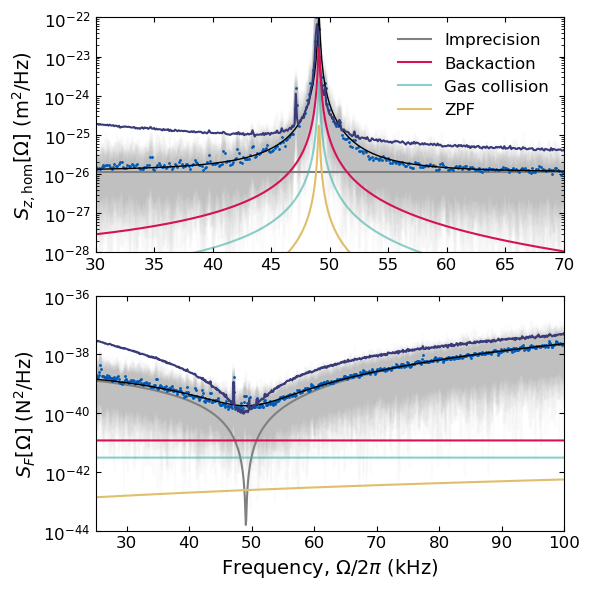

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

for i, zpp in enumerate(z_pp_welch):
    axes[0].plot(ff_welch/1000, zpp, 'silver', alpha=0.05, zorder=-5)
    axes[1].plot(ff_welch/1000, f_pp_welch[i],'silver', alpha=0.05, zorder=-5)

chi_welch = 1 / (m_sphere * (omega0_welch**2 - omega_welch**2 - 1j*gamma_welch*omega_welch))

axes[0].plot(ff_welch/1000, sz_average_welch, '.', color='#005AB5', markersize=2)
axes[0].plot(ff_welch/1000, sz_imp + sf_measure * np.abs(chi_welch)**2, color='k', linewidth=1)

axes[1].plot(ff_welch/1000, sf_average_welch, '.', color='#005AB5', markersize=2)
axes[1].plot(ff_welch/1000, sz_imp/np.abs(chi_welch)**2 + sf_measure, color='k', linewidth=1)
axes[0].plot(ff/1000, np.mean(z_pp, axis=0))
axes[1].plot(ff/1000, np.mean(f_pp, axis=0))

gamma = gamma_welch

axes[0].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp/eff), 'grey', linewidth=1.5, label='Imprecision', zorder=-5)
axes[0].plot(omega_theory/(1000*2*pi), 4 * S_ff_ba * np.abs(chi_ba)**2, color='#D41159', linewidth=1.5, label='Backaction')
axes[0].plot(omega_theory/(1000*2*pi), sf_th * np.abs(chi_ba)**2, color='#40B0A6', linewidth=1.5, alpha=0.6, label='Gas collision')
axes[0].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf, color='#E1BE6A', linewidth=1.5, label='ZPF')

axes[1].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp/eff/(np.abs(chi_ba)**2)), 'grey', linewidth=1.5, zorder=-5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, 2*S_ff_ba) , color='#D41159', linewidth=1.5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, sf_th), color='#40B0A6', linewidth=1.5, alpha=0.6)
axes[1].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf/(np.abs(chi_ba)**2), color='#E1BE6A', linewidth=1.5)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(25, 100)

axes[0].legend(frameon=False)
axes[0].set_ylabel(r'$S_{z, \mathrm{hom}}[\Omega]$ (m$^2$/Hz)')
axes[1].set_ylabel(r'$S_{F}[\Omega]$ (N$^2$/Hz)')
axes[1].set_xlabel(r'Frequency, $\Omega / 2 \pi$ (kHz)')

axes[0].set_xlim(30, 70)
axes[0].set_ylim(1e-28, 1e-22)
axes[1].set_ylim(1e-44, 1e-36)

fig.tight_layout()
fig.align_labels()


In [5]:
kb = 1.38e-23

p_mbar = 1e-8
p_pascal = p_mbar * 100

R = 8.3144  # J/(mol K)
m_gas = 2.016e-3 * 0.5 + 18.01528e-3 * 0.5  # kg / mol
T = 292  # K
vbar = np.sqrt(8 * R * T / (np.pi * m_gas))  # m/s

r_sphere_0 = 83.5e-9
m_sphere_0 = 2000 * 4/3 * np.pi * r_sphere_0**3

gamma_th = (64/3) * r_sphere_0**2 * p_pascal / (m_sphere_0 * vbar)
sf_th = 4 * kb * T * gamma_th * m_sphere_0

In [534]:
omega0 = 49000 * 2 * np.pi
gamma_reheating = 3250 * 2 * np.pi

zpf = np.sqrt(hbar / (2 * m * omega0))

S_ff_ba = hbar**2 * gamma_reheating / (zpf**2)  # N^2 / Hz
S_zz_imp = (zpf**2) / (4 * gamma_reheating)     # m^2 / Hz

# Always integrate over double-sided spectra to avoid confusion...
# also numerical integration over one-sided spectra gives incorrect values sometimes
# look into more in the future
omega_theory = np.linspace(-2*300e3*np.pi, 2*300e3*np.pi, 10000)

pi = np.pi
zpf = np.sqrt(hbar / (2 * m * omega0))  # Zero point fluctuation (m)

gamma = 122.0703125 * 2 * np.pi

# ZPF
S_zz_zpf = 0.5 * zpf**2 * gamma / ( (omega_theory-omega0)**2 + (gamma/2)**2 )

chi_ba = (1 / m) / (omega0**2 - omega_theory**2 - gamma * omega_theory * 1j) # Complex susceptibility
S_zz_tot = np.full_like(omega_theory, S_zz_imp) + S_ff_ba * np.abs(chi_ba) * np.abs(chi_ba) + S_zz_zpf

# ZPF force noise (single sided)
S_f_zpf = 2 * hbar * m * gamma * omega0

# SQL curves
S_z_sql = 2 * hbar * (np.abs(chi_ba))
S_f_sql = 2 * hbar / (np.abs(chi_ba))

In [537]:
S_f_zpf

2.385749885632362e-43

In [18]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3)(, E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C

na = 0.77
lambd = 1064e-9
k = 2 * np.pi / lambd

A = calc_geometric_factor(na=na)
p_sca = S_ff_ba / ((A**2 + 2/5) * hbar * k / c)

print(f'Scattered laser power = {p_sca*1e6:.2f} uW')
print(f'Backaction noise] (one-sided): {S_ff_ba * 2:.3e} N^2/Hz')
print(f'Imprecision noise floor (one-sided): {S_zz_imp * 2:.3e} m^2/Hz')

Scattered laser power = 2.59 uW
Backaction noise] (one-sided): 1.173e-41 N^2/Hz
Imprecision noise floor (one-sided): 9.484e-28 m^2/Hz


In [19]:
c_mv * 0.8

5.945545123629056e-08

In [20]:
(0.77 / 0.95)**4

0.4315871241012578

(1e-14, 1e-06)

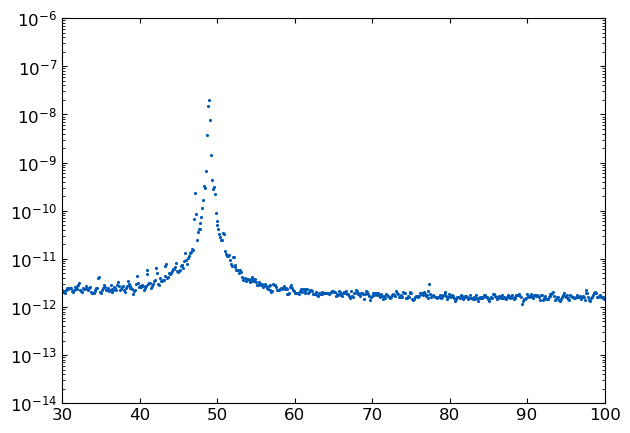

In [21]:
plt.plot(ff_welch/1000, sz_average_welch/(c_mv**2), '.', color='#005AB5', markersize=2.5)
plt.yscale('log')

plt.xlim(30, 100)
plt.ylim(1e-14, 1e-6)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


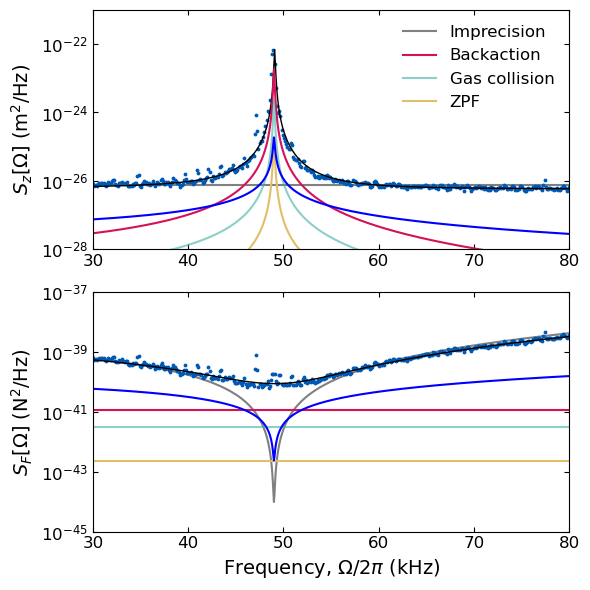

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

factor = 0.8**2
axes[0].plot(ff_welch/1000, sz_average_welch*factor, '.', color='#005AB5', markersize=3.5)
axes[0].plot(ff_welch/1000, (sz_imp + sf_measure * np.abs(chi_welch)**2)*factor, color='k', linewidth=1)
axes[1].plot(ff_welch/1000, sf_average_welch*factor, '.', color='#005AB5', markersize=3.5)
axes[1].plot(ff_welch/1000, ((sz_imp/np.abs(chi_welch)**2 + sf_measure))*factor, color='k', linewidth=1)

axes[0].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp) * 8, 'grey', linewidth=1.5, label='Imprecision', zorder=-5)
axes[0].plot(omega_theory/(1000*2*pi), 4 * S_ff_ba * np.abs(chi_ba)**2, color='#D41159', linewidth=1.5, label='Backaction')
axes[0].plot(omega_theory/(1000*2*pi), sf_th * np.abs(chi_ba)**2, color='#40B0A6', linewidth=1.5, alpha=0.6, label='Gas collision')
axes[0].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf, color='#E1BE6A', linewidth=1.5, label='ZPF')

axes[0].plot(omega_theory/(1000*2*pi), S_z_sql, color='b', linewidth=1.5)

axes[1].plot(omega_theory/(2*np.pi*1000), np.full_like(omega_theory, 2*S_zz_imp/(np.abs(chi_ba)**2)) * 8, 'grey', linewidth=1.5, zorder=-5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, 2*S_ff_ba) , color='#D41159', linewidth=1.5)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, sf_th), color='#40B0A6', linewidth=1.5, alpha=0.6)
# axes[1].plot(omega_theory/(1000*2*pi), 2 * S_zz_zpf/(np.abs(chi_ba)**2), color='#E1BE6A', linewidth=1.5)
# sf_total = 2*S_zz_imp/(np.abs(chi_ba)**2) + 2*S_ff_ba + sf_th + 2 * S_zz_zpf/(np.abs(chi_ba)**2)
axes[1].plot(omega_theory/(1000*2*pi), np.full_like(omega_theory, S_f_zpf), color='#E1BE6A', linewidth=1.5)
sf_total = 2*S_zz_imp/(np.abs(chi_ba)**2) + 2*S_ff_ba + sf_th + S_f_zpf

axes[1].plot(omega_theory/(1000*2*pi), S_f_sql, color='b', linewidth=1.5)

# axes[1].plot(omega_theory/(1000*2*pi), sf_total, '--', color='k', linewidth=1.5, label='Total force noise')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(25, 100)

axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
axes[0].set_ylabel(r'$S_{z}[\Omega]$ (m$^2$/Hz)')
axes[1].set_ylabel(r'$S_{F}[\Omega]$ (N$^2$/Hz)')
axes[1].set_xlabel(r'Frequency, $\Omega / 2 \pi$ (kHz)')

axes[0].set_xlim(30, 80)
axes[1].set_xlim(30, 80)

axes[0].set_ylim(1e-28, 1e-21)
axes[1].set_ylim(1e-45, 1e-37)
# axes[1].set_ylim(1e-42, 1e-39)

fig.tight_layout()
fig.align_labels()

# plt.savefig('../paper_plots/noise_budget_theory.png', transparent=True)


In [21]:
np.trapz(np.full_like(omega_theory, S_f_zpf/2), omega_theory) * SI2ev / 1000

8.57930098574848e-13

In [305]:
idx_int = np.logical_and(ff_welch>20000, ff_welch<200000)
dp_kev = np.empty(f_pp_welch.shape[0])

for i, f_pp in enumerate(np.real(f_pp_welch)):
    dp_kev[i] = np.sqrt( 1/( np.trapz(1/f_pp[idx_int], x=omega_welch[idx_int]) /(2*np.pi) ) ) * SI2ev / 1000


# sf_total = sz_imp/np.abs(chi_welch)**2 + sf_measure
# delta_p_kev_theory = np.sqrt(1/(np.trapz(1/(sff_total), x=omega_theory)/(2*np.pi))) * SI2ev / 1000

# print(delta_p_kev)

In [314]:
np.sqrt(np.mean(dp_kev**2))

72.43150802414034

In [ ]:
s_f, omega0

def sz_model_log(omega, s_imp):
    chi = (1 / m_sphere) / (omega0**2 - omega**2 - 1j*gamma_welch*omega)
    return np.log(np.full_like(omega, s_imp) + np.abs(chi)**2 * s_f)

In [ ]:
omega0 = ff_welch[ff_welch>20000][np.argmax(sz_average_welch[ff_welch > 20000])] * 2 * np.pi


idx = np.logical_and(ff_welch > 150000, ff_welch < 200000)
s_zz_imp = np.mean((z_pp_welch.T)[idx])


In [91]:
from scipy.optimize import curve_fit

idx_fit = np.logical_and(ff_welch > 30000, ff_welch < 55000)
popt, pcov = curve_fit(sz_model_log, ff_welch[idx_fit]*2*np.pi, np.log(sz_average_welch[idx_fit]),
                       p0=[1e-26, 1e-40, 49000*2*np.pi],
                       bounds=([1e-27, 1e-45, 45000*2*np.pi], [1e-25, 1e-35, 51000*2*np.pi]))


In [86]:
m_sphere

4.87728384838876e-18

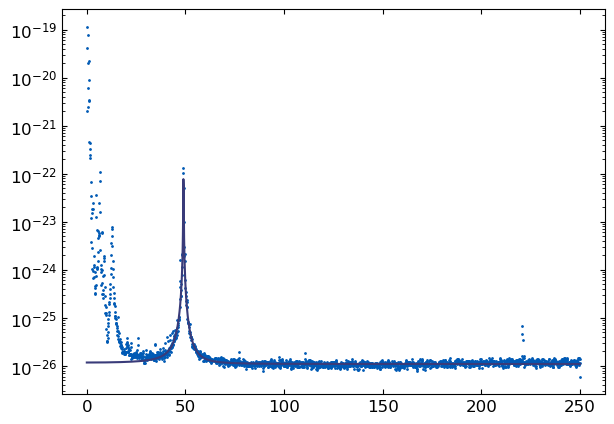

In [102]:
plt.plot(ff_welch/1000, sz_average_welch, '.', color='#005AB5', markersize=2)
# plt.plot(ff_welch/1000, np.exp(sz_model_log(ff_welch*2*np.pi, *popt)))

plt.plot(ff_welch/1000, np.exp(sz_model_log(ff_welch*2*np.pi, 1.1e-26, 1.7e-40, 49000*2*np.pi)))
plt.yscale('log')


In [812]:
gamma_reheating / (2 * np.pi)

5643.952487667024

In [814]:
gamma_meas

125.89832241473512

In [815]:
gamma_meas / gamma_reheating

0.0035502319310921175

In [783]:
sff_total = S_zz_imp/eff/(np.abs(chi_ba)**2) + S_ff_ba + S_zz_zpf/(np.abs(chi_ba)**2)

In [658]:
delta_p_kev_theory

51.22778169929389

In [636]:
np.sqrt(hbar * m * omega0) * SI2ev / 1000

23.300530672950263

In [411]:
omega0 / (2 * np.pi)

47851.5625

In [132]:
(1064 / 1550) ** 4

0.22204434605662454

In [163]:
ff[ff>20000][278]

47900.0

In [136]:
m_eth

1.1519173063162574e-18

In [138]:
m_eth = 2200 * (50e-9**3) * (4 / 3) * np.pi  # sphere mass
omega_eth = 55500 * 2 * np.pi

zpf_eth = np.sqrt(hbar / (2 * m_eth * omega0))  # Zero point fluctuation (m)

In [142]:
sf_ba_eth = 2 * hbar**2 * 3770 * 2 * np.pi/ (zpf_eth**2)

In [152]:
sf_ba_eth * zpf**2 / (hbar**2) / (2 * np.pi)

1780.79782920444

In [150]:
(hbar**2 / sf_ba_eth) / (1.3e-26)

0.24105398623197546

In [108]:
(zpf_eth**2) / (1e-26 * 8 * np.pi)

649.7730725876012

In [109]:
649 / 3770

0.17214854111405836

In [112]:
(zpf**2) / (1e-26 * 8 * np.pi) / 4000

0.03487805875149203